In [52]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,classification_report, )
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [53]:
df = pd.read_csv("./data/df_final_janeiro_22.csv")
df

,Autoavaliacao_Saude,Idade,Sexo,Cor_Raca,Estado_Civil,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,...,Freq_Depressao,Grau_Limite_Depressao,Grau_Limite_Doenca_Mental,Grau_Limite_DORT,Pratica_Exercicio,Horas_TV,Fuma,Freq_Alcool,Apoio_Familiar,Apoio_Amigos
0,3.0,55.0,2.0,1.0,1.0,1.0,6.0,5.0,2.0,2.0,...,2.0,2.0,2.0,1.0,1.0,3.0,3.0,2.0,3.0,0.0
1,2.0,19.0,2.0,4.0,4.0,1.0,4.0,4.0,1.0,2.0,...,1.0,2.0,2.0,2.0,2.0,6.0,1.0,2.0,3.0,2.0
2,3.0,45.0,2.0,2.0,4.0,1.0,8.0,8.0,4.0,2.0,...,1.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,1.0
3,3.0,58.0,2.0,2.0,3.0,1.0,1.0,1.0,0.0,2.0,...,1.0,2.0,2.0,2.0,1.0,1.0,3.0,1.0,1.0,0.0
4,2.0,28.0,2.0,4.0,4.0,2.0,2.0,2.0,1.0,2.0,...,1.0,2.0,2.0,2.0,1.0,2.0,3.0,1.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90841,3.0,54.0,2.0,4.0,1.0,1.0,3.0,5.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0,3.0
90842,2.0,44.0,1.0,4.0,2.0,1.0,2.0,5.0,1.0,1.0,...,1.0,2.0,2.0,2.0,2.0,6.0,1.0,3.0,2.0,2.0
90843,2.0,32.0,2.0,4.0,1.0,2.0,4.0,4.0,1.0,2.0,...,2.0,2.0,2.0,2.0,1.0,4.0,3.0,1.0,3.0,0.0
90844,3.0,54.0,1.0,4.0,1.0,1.0,3.0,10.0,3.0,1.0,...,2.0,1.0,2.0,1.0,1.0,2.0,3.0,1.0,1.0,3.0


In [54]:
# target = "Saude_Boa"
target = "Autoavaliacao_Saude"

In [43]:
df['Saude_Boa'] = df['Autoavaliacao_Saude'].map({
    1: 1,  # Muito boa
    2: 1,  # Boa
    3: 0,  # Regular
    4: 0,  # Ruim
    5: 0   # Muito ruim
})
df

,Autoavaliacao_Saude,Idade,Sexo,Cor_Raca,Estado_Civil,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,...,Grau_Limite_Depressao,Grau_Limite_Doenca_Mental,Grau_Limite_DORT,Pratica_Exercicio,Horas_TV,Fuma,Freq_Alcool,Apoio_Familiar,Apoio_Amigos,Saude_Boa
0,3.0,55.0,2.0,1.0,1.0,1.0,6.0,5.0,2.0,2.0,...,2.0,2.0,1.0,1.0,3.0,3.0,2.0,3.0,0.0,0
1,2.0,19.0,2.0,4.0,4.0,1.0,4.0,4.0,1.0,2.0,...,2.0,2.0,2.0,2.0,6.0,1.0,2.0,3.0,2.0,1
2,3.0,45.0,2.0,2.0,4.0,1.0,8.0,8.0,4.0,2.0,...,2.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,1.0,0
3,3.0,58.0,2.0,2.0,3.0,1.0,1.0,1.0,0.0,2.0,...,2.0,2.0,2.0,1.0,1.0,3.0,1.0,1.0,0.0,0
4,2.0,28.0,2.0,4.0,4.0,2.0,2.0,2.0,1.0,2.0,...,2.0,2.0,2.0,1.0,2.0,3.0,1.0,3.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90841,3.0,54.0,2.0,4.0,1.0,1.0,3.0,5.0,1.0,1.0,...,2.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0,3.0,0
90842,2.0,44.0,1.0,4.0,2.0,1.0,2.0,5.0,1.0,1.0,...,2.0,2.0,2.0,2.0,6.0,1.0,3.0,2.0,2.0,1
90843,2.0,32.0,2.0,4.0,1.0,2.0,4.0,4.0,1.0,2.0,...,2.0,2.0,2.0,1.0,4.0,3.0,1.0,3.0,0.0,1
90844,3.0,54.0,1.0,4.0,1.0,1.0,3.0,10.0,3.0,1.0,...,1.0,2.0,1.0,1.0,2.0,3.0,1.0,1.0,3.0,0


Separando X e Y

In [55]:
X = df.drop(columns=[target, "Autoavaliacao_Saude"])
y = df[target]


Fazendo onehot encoding

In [56]:
# dataset 18 de janeiro
cols_nominais = [
    'Sexo', 'Cor_Raca', 'Estado_Civil',
    'Possui_Automovel', 'Possui_Computador',
    'Acesso_Internet', 'Diagnostico_Doenca_Cronica',
    'Pratica_Exercicio', 'Fuma'
]

# dataset 22 de janeiro
cols_nominais = [
    'Sexo', 'Cor_Raca', 'Estado_Civil',
    'Possui_Automovel', 'Possui_Computador',
    'Acesso_Internet',
    'Pratica_Exercicio', 'Fuma'
]
X = pd.get_dummies(X, columns=cols_nominais, drop_first=True)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)

Treinando Árvore de Decisão

In [58]:
model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=200,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,200
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [59]:
y_pred_cont = model.predict(X_test)
y_pred = np.clip(np.round(y_pred_cont), 1, 5).astype(int)


In [ ]:
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[2256  483  652  130   78]
 [5927 2286 3724 1007  504]
 [1527 1085 3245 1537  981]
 [ 102   98  428  426  426]
 [  13   12   62  110  155]]
              precision    recall  f1-score   support

         1.0       0.23      0.63      0.34      3599
         2.0       0.58      0.17      0.26     13448
         3.0       0.40      0.39      0.39      8375
         4.0       0.13      0.29      0.18      1480
         5.0       0.07      0.44      0.12       352

    accuracy                           0.31     27254
   macro avg       0.28      0.38      0.26     27254
weighted avg       0.45      0.31      0.31     27254



In [64]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report


,precision,recall,f1-score,support
1.0,0.229618,0.626841,0.336114,3599.000000
2.0,0.576690,0.169988,0.262578,13448.000000
3.0,0.400074,0.387463,0.393667,8375.000000
4.0,0.132710,0.287838,0.181663,1480.000000
5.0,0.072295,0.440341,0.124199,352.000000
accuracy,0.307037,0.307037,0.307037,0.307037
macro avg,0.282278,0.382494,0.259644,27254.000000
weighted avg,0.445960,0.307037,0.306390,27254.000000


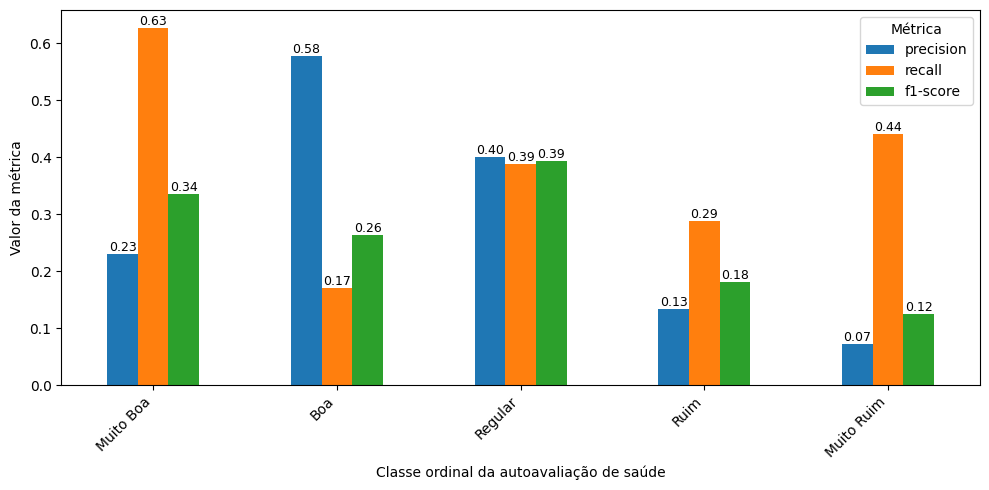

In [105]:
map_classes = {
    "1.0": "Muito Boa",
    "2.0": "Boa",
    "3.0": "Regular",
    "4.0": "Ruim",
    "5.0": "Muito Ruim"
}



df_plot = df_report.loc[["1.0", "2.0", "3.0", "4.0", "5.0"]]
df_plot = df_plot.rename(index=map_classes)

ax = df_plot[["precision", "recall", "f1-score"]].plot(
    kind="bar",
    figsize=(10,5)
)

# plt.title("Classification Report por classe – Árvore de Decisão")
plt.xlabel("Classe ordinal da autoavaliação de saúde")
plt.ylabel("Valor da métrica")
plt.legend(title="Métrica")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, padding=0)


plt.tight_layout()
plt.show()


In [70]:
importances = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print(importances.head(20))


                      feature  importance
8              Freq_Depressao    0.389079
0                       Idade    0.250996
26      Possui_Computador_2.0    0.125983
7               Freq_Anedonia    0.058229
28      Pratica_Exercicio_2.0    0.045623
6                Freq_Cansaco    0.040981
1             Nivel_Instrucao    0.027158
5         Freq_Problemas_Sono    0.025022
13                Freq_Alcool    0.009477
3                 Qtd_Comodos    0.006160
27        Acesso_Internet_2.0    0.006132
25       Possui_Automovel_2.0    0.005942
15               Apoio_Amigos    0.005881
2             Total_Moradores    0.003338
4               Qtd_Banheiros    0.000000
14             Apoio_Familiar    0.000000
12                   Horas_TV    0.000000
11           Grau_Limite_DORT    0.000000
10  Grau_Limite_Doenca_Mental    0.000000
9       Grau_Limite_Depressao    0.000000


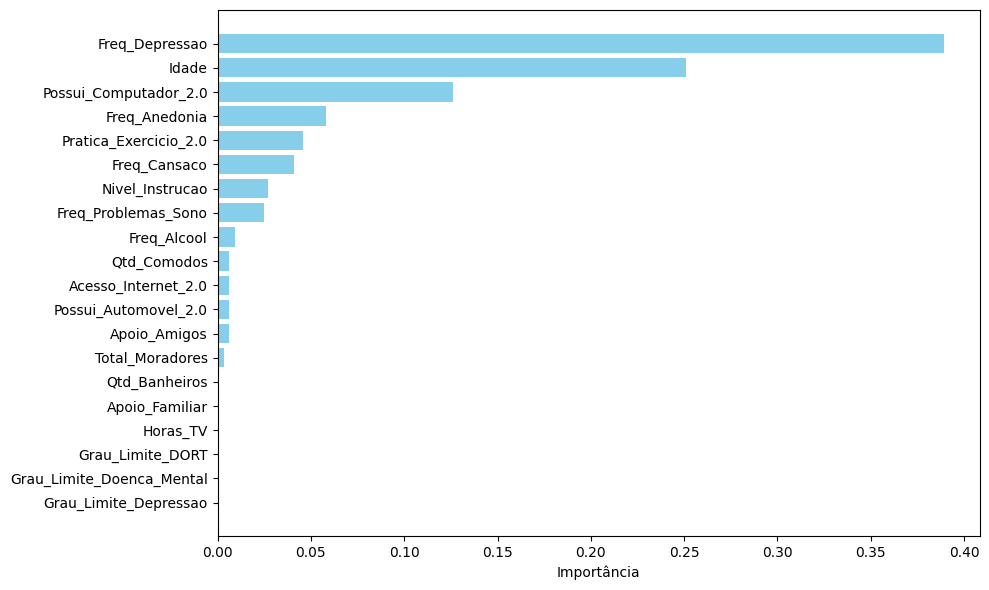

In [71]:
import matplotlib.pyplot as plt

top_features = importances.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1], color='skyblue')  # invertendo para melhor visualização (maior em cima)
plt.xlabel("Importância")
# plt.title("Top 20 Variáveis mais importantes - Decision Tree")
plt.tight_layout()
plt.show()


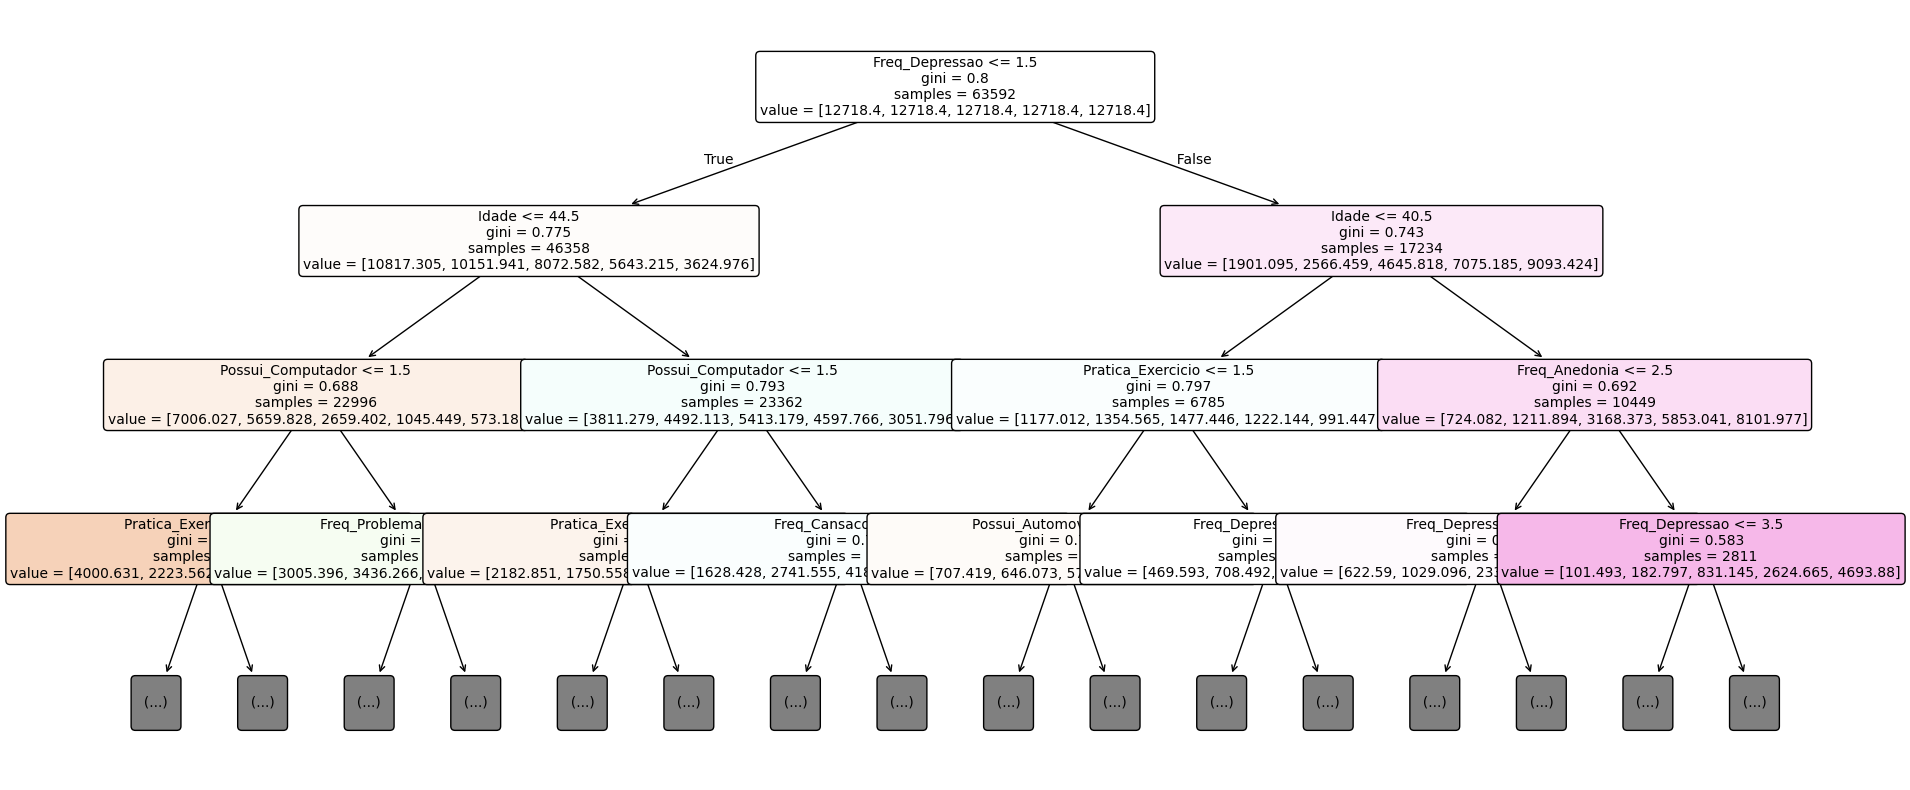

In [21]:
plt.figure(figsize=(22, 10))

plot_tree(
    model,
    feature_names=X.columns,
    # class_names=["Saúde Ruim", "Saúde Boa"], 
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.show()


In [ ]:
plt.figure(figsize=(22, 10))
plot_tree(model, feature_names=X.columns, filled=True, rounded=True, fontsize=10, max_depth=3)
plt.savefig("arvore_decisao.pdf", bbox_inches='tight')


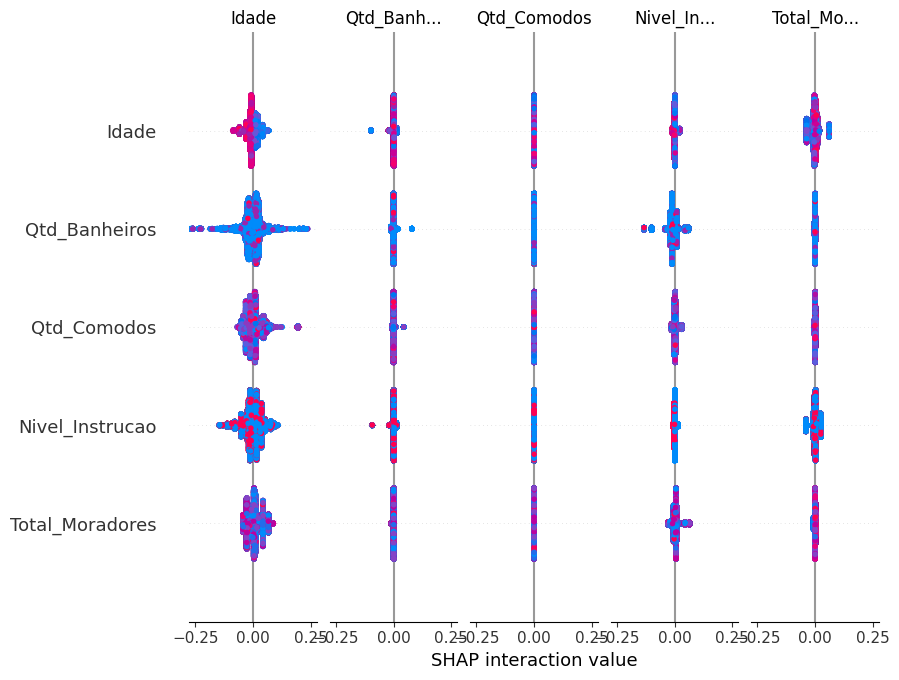

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train)